In [1]:
import importlib.util, subprocess, sys
if importlib.util.find_spec('pyspark') is None:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'pyspark', 'pyarrow'], check=True)
import pyspark; print('pyspark', pyspark.__version__)

pyspark 4.0.4


In [2]:
# ===== Self-contained setup: rebuilds the data this notebook needs in a fresh Colab session =====
import os, math, time, requests
from pathlib import Path
from pyspark.sql import SparkSession, functions as F

YEAR, MONTHS = 2024, [1, 2, 3]
BASE = Path('..') if Path('../data').exists() else Path('.')
RAW, LAKE = BASE / 'data' / 'raw', BASE / 'data' / 'lake'
for _p in (RAW, LAKE, BASE / 'results', BASE / 'models'):
    _p.mkdir(parents=True, exist_ok=True)
URL = 'https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_{y}-{m:02d}.parquet'
ZONES_URL = 'https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv'

def get_spark(name='nyc-taxi'):
    return (SparkSession.builder.appName(name).master('local[*]')
            .config('spark.driver.memory', '4g').config('spark.sql.shuffle.partitions', '16').getOrCreate())

def _download(url, dest):
    if dest.exists():
        return
    r = requests.get(url, stream=True, timeout=120); r.raise_for_status()
    with open(dest, 'wb') as f:
        for chunk in r.iter_content(chunk_size=1 << 20):
            f.write(chunk)
    print('downloaded', dest.name, round(dest.stat().st_size / 1e6, 1), 'MB')

def ensure_raw_zone():
    """Download TLC files and write the partitioned Parquet raw zone (same as Stage 1)."""
    if (LAKE / 'raw_zone' / 'yellow_trips').exists() and (LAKE / 'raw_zone' / 'taxi_zones').exists():
        print('raw zone ready'); return
    spark = get_spark(); files = []
    for m in MONTHS:
        dest = RAW / f'yellow_tripdata_{YEAR}-{m:02d}.parquet'
        _download(URL.format(y=YEAR, m=m), dest); files.append(str(dest))
    _download(ZONES_URL, RAW / 'taxi_zone_lookup.csv')
    df = spark.read.parquet(*files).withColumn('pickup_month', F.date_format('tpep_pickup_datetime', 'yyyy-MM'))
    df.write.mode('overwrite').partitionBy('pickup_month').parquet(str(LAKE / 'raw_zone' / 'yellow_trips'))
    zones = spark.read.csv(str(RAW / 'taxi_zone_lookup.csv'), header=True, inferSchema=True)
    zones.write.mode('overwrite').parquet(str(LAKE / 'raw_zone' / 'taxi_zones'))
    print('raw zone written')

def ensure_curated_zone():
    """Clean, engineer features and split 70/15/15 (same rules as Stage 2)."""
    cz = LAKE / 'curated_zone'
    if (cz / 'test').exists():
        print('curated zone ready'); return
    ensure_raw_zone(); spark = get_spark()
    cols = ['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance',
            'RatecodeID', 'PULocationID', 'DOLocationID', 'fare_amount', 'pickup_month']
    df = spark.read.parquet(str(LAKE / 'raw_zone' / 'yellow_trips')).select(*cols).dropna().dropDuplicates()
    df = (df.withColumn('duration_min', (F.unix_timestamp('tpep_dropoff_datetime') - F.unix_timestamp('tpep_pickup_datetime')) / 60)
            .withColumn('speed_mph', F.col('trip_distance') / (F.col('duration_min') / 60)))
    valid_months = [f'{YEAR}-{m:02d}' for m in MONTHS]
    df = df.filter(F.col('pickup_month').isin(valid_months) & F.col('fare_amount').between(3, 200) &
                   F.col('trip_distance').between(0.1, 100) & F.col('passenger_count').between(1, 6) &
                   F.col('RatecodeID').between(1, 6) & F.col('PULocationID').between(1, 263) &
                   F.col('DOLocationID').between(1, 263) & F.col('duration_min').between(1, 180) &
                   (F.col('speed_mph') < 80))
    df = (df.withColumn('hour', F.hour('tpep_pickup_datetime'))
            .withColumn('dow', (F.dayofweek('tpep_pickup_datetime') + 5) % 7)
            .withColumn('is_weekend', (F.col('dow') >= 5).cast('int'))
            .withColumn('hour_sin', F.sin(2 * math.pi * F.col('hour') / 24))
            .withColumn('hour_cos', F.cos(2 * math.pi * F.col('hour') / 24)))
    for c in ['passenger_count', 'RatecodeID', 'PULocationID', 'DOLocationID']:
        df = df.withColumn(c, F.col(c).cast('int'))
    df = (df.withColumn('trip_distance', F.col('trip_distance').cast('double'))
            .withColumn('fare_amount', F.col('fare_amount').cast('double'))
            .select('trip_distance', 'passenger_count', 'hour', 'dow', 'is_weekend', 'hour_sin', 'hour_cos',
                    'PULocationID', 'DOLocationID', 'RatecodeID', 'fare_amount', 'pickup_month'))
    df.write.mode('overwrite').parquet(str(cz / 'all'))      # materialise once -> reproducible split
    df = spark.read.parquet(str(cz / 'all')).withColumn('_r', F.rand(42))
    df.filter(F.col('_r') < 0.70).drop('_r').write.mode('overwrite').parquet(str(cz / 'train'))
    df.filter((F.col('_r') >= 0.70) & (F.col('_r') < 0.85)).drop('_r').write.mode('overwrite').parquet(str(cz / 'val'))
    df.filter(F.col('_r') >= 0.85).drop('_r').write.mode('overwrite').parquet(str(cz / 'test'))
    print('curated zone written')

def ensure_model_zone(frac=0.20):
    """Export the pandas-friendly sample used for neural-network training (same as Stage 3)."""
    mz, cz = LAKE / 'model_zone', LAKE / 'curated_zone'
    if (mz / 'test').exists():
        print('model zone ready'); return
    ensure_curated_zone(); spark = get_spark()
    for name in ['train', 'val', 'test']:
        s = spark.read.parquet(str(cz / name)).drop('pickup_month').sample(False, frac, seed=42)
        s.write.mode('overwrite').parquet(str(mz / name))
    print('model zone written')

ensure_model_zone()
get_spark().stop()   # free memory for TensorFlow

downloaded yellow_tripdata_2024-01.parquet 50.0 MB
downloaded yellow_tripdata_2024-02.parquet 50.3 MB
downloaded yellow_tripdata_2024-03.parquet 60.1 MB
downloaded taxi_zone_lookup.csv 0.0 MB
raw zone written
curated zone written
model zone written


## Shared helper code (from `src/utils.py`, included here so this notebook is standalone)

In [3]:
"""Shared helpers for stages 4-6 (data loading, scaling, model building, evaluation, logging)."""
import json, time
from pathlib import Path
import numpy as np
import pandas as pd

BASE = Path('..') if Path('../data').exists() else Path('.')
LAKE = BASE / 'data' / 'lake'
MODEL_ZONE = LAKE / 'model_zone'
MODELS = BASE / 'models'
RESULTS = BASE / 'results'
for _p in (MODELS, RESULTS):
    _p.mkdir(parents=True, exist_ok=True)

NUM_COLS = ['trip_distance', 'passenger_count', 'hour', 'dow', 'is_weekend', 'hour_sin', 'hour_cos']
CAT_COLS = ['PULocationID', 'DOLocationID', 'RatecodeID']
TARGET = 'fare_amount'
VOCAB = {'PULocationID': 266, 'DOLocationID': 266, 'RatecodeID': 8}
SEED = 42
LOG_FILE = RESULTS / 'experiment_log.csv'


def load_split(name):
    """Load a split exported by Stage 3 (train / val / test) as a pandas DataFrame."""
    return pd.read_parquet(MODEL_ZONE / name)


def fit_scaler(train_df):
    """Mean/std computed on TRAIN only (avoids leakage)."""
    stats = {c: (float(train_df[c].mean()), float(train_df[c].std() or 1.0)) for c in NUM_COLS}
    (MODELS / 'scaler.json').write_text(json.dumps(stats))
    return stats


def make_xy(df, scaler, cfg):
    num = np.column_stack([(df[c].values - scaler[c][0]) / scaler[c][1] for c in NUM_COLS]).astype('float32')
    x = {'num': num}
    if cfg.get('embed'):
        for c in CAT_COLS:
            x[c] = df[c].values.astype('int32').reshape(-1, 1)
    y = df[TARGET].values.astype('float32')
    if cfg.get('log_target'):
        y = np.log1p(y)
    return x, y


def build_model(cfg, n_num=len(NUM_COLS)):
    import tensorflow as tf
    from tensorflow.keras import layers, Model
    num_in = layers.Input(shape=(n_num,), name='num')
    inputs, feats = [num_in], [num_in]
    if cfg.get('embed'):
        for c in CAT_COLS:
            i = layers.Input(shape=(1,), name=c, dtype='int32')
            inputs.append(i)
            e = layers.Flatten()(layers.Embedding(VOCAB[c], cfg.get('embed_dim', 8))(i))
            feats.append(e)
    x = layers.Concatenate()(feats) if len(feats) > 1 else num_in
    for units in cfg['hidden']:
        x = layers.Dense(units, activation='relu')(x)
        if cfg.get('dropout', 0) > 0:
            x = layers.Dropout(cfg['dropout'])(x)
    out = layers.Dense(1)(x)
    model = Model(inputs, out)
    loss = tf.keras.losses.Huber() if cfg.get('loss') == 'huber' else 'mse'
    model.compile(optimizer=tf.keras.optimizers.Adam(cfg.get('lr', 1e-3)), loss=loss, metrics=['mae'])
    return model


def metrics(y_true, y_pred):
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    return {'mae': float(mean_absolute_error(y_true, y_pred)),
            'rmse': float(np.sqrt(mean_squared_error(y_true, y_pred))),
            'r2': float(r2_score(y_true, y_pred))}


def predict_dollars(model, x, cfg):
    p = model.predict(x, batch_size=4096, verbose=0).ravel()
    return np.expm1(p) if cfg.get('log_target') else p


def log_result(name, kind, cfg, split_metrics, train_seconds=None, n_params=None, split='val'):
    row = {'name': name, 'kind': kind, 'split': split, **split_metrics,
           'train_seconds': train_seconds, 'n_params': n_params,
           'config': json.dumps(cfg, sort_keys=True), 'timestamp': pd.Timestamp.now().isoformat(timespec='seconds')}
    df = pd.DataFrame([row])
    df.to_csv(LOG_FILE, mode='a', header=not LOG_FILE.exists(), index=False)
    return row


def train_eval_nn(name, cfg, train, val, scaler, verbose=0):
    """Train a Keras model with early stopping, evaluate on VALIDATION in dollars, log the result."""
    import tensorflow as tf
    tf.keras.utils.set_random_seed(SEED)
    xtr, ytr = make_xy(train, scaler, cfg)
    xva, _ = make_xy(val, scaler, cfg)
    model = build_model(cfg)
    es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    yva_t = np.log1p(val[TARGET].values) if cfg.get('log_target') else val[TARGET].values
    t0 = time.time()
    hist = model.fit(xtr, ytr, validation_data=(xva, yva_t.astype('float32')),
                     epochs=cfg.get('epochs', 20), batch_size=cfg.get('batch_size', 1024),
                     callbacks=[es], verbose=verbose)
    secs = time.time() - t0
    m = metrics(val[TARGET].values, predict_dollars(model, xva, cfg))
    log_result(name, 'neural_network', cfg, m, secs, model.count_params(), 'val')
    return model, hist, m

# Stage 6: Final Model and Test Evaluation
The best neural-network configuration (lowest validation RMSE in the log) is retrained and evaluated **once** on the untouched test set, next to the baselines.

In [4]:
import json, time
import numpy as np, pandas as pd, matplotlib.pyplot as plt
train, val, test = load_split('train'), load_split('val'), load_split('test')
scaler = fit_scaler(train)

# The Stage 5 log is not available in this new session, so the best configuration is set by hand.
# From Stage 5's comparison table, Exp3 (embeddings) had the lowest validation RMSE (2.43).
best_cfg = {'embed': True, 'embed_dim': 8, 'hidden': [256, 128, 64], 'dropout': 0.1,
            'lr': 1e-3, 'batch_size': 1024, 'epochs': 15}
best_cfg


{'embed': True,
 'embed_dim': 8,
 'hidden': [256, 128, 64],
 'dropout': 0.1,
 'lr': 0.001,
 'batch_size': 1024,
 'epochs': 15}

## 1. Retrain the selected configuration

In [5]:
model, hist, m_val = train_eval_nn('nn_final', best_cfg, train, val, scaler, verbose=1)
model.save(str(MODELS / 'final_model.keras'))
m_val

Epoch 1/15
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 27s 22ms/step - loss: 28.6619 - mae: 2.8818 - val_loss: 8.2246 - val_mae: 1.7280
Epoch 2/15
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 23s 21ms/step - loss: 10.8982 - mae: 2.1378 - val_loss: 7.0460 - val_mae: 1.6183
Epoch 3/15
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 43s 22ms/step - loss: 9.9069 - mae: 2.0326 - val_loss: 6.4478 - val_mae: 1.5529
Epoch 4/15
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 24s 21ms/step - loss: 9.4537 - mae: 1.9809 - val_loss: 6.3323 - val_mae: 1.5155
Epoch 5/15
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 42s 22ms/step - loss: 9.1766 - mae: 1.9472 - val_loss: 6.4124 - val_mae: 1.5307
Epoch 6/15
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 24s 21ms/step - loss: 8.9482 - mae: 1.9214 - val_loss: 6.2756 - val_mae: 1.5217
Epoch 7/15
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 42s 22ms/step - loss: 8.7003 - mae: 1.8954 - val_loss: 6.3930 - val_mae: 1.5417
Epoch 8/15
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 24s 22ms/step - loss: 8.5811 - mae: 1.8826 - val_loss: 5.9991 - val_mae: 1.5281
Epoch 9/15
1133/1133 ━

{'mae': 1.5020786379493236,
 'rmse': 2.432674552553263,
 'r2': 0.9761355753345812}

## 2. One-time test evaluation, final NN vs baselines

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

xte, _ = make_xy(test, scaler, best_cfg)
pred_nn = predict_dollars(model, xte, best_cfg)

lin = LinearRegression().fit(train[NUM_COLS], train[TARGET])
feats = NUM_COLS + CAT_COLS
sub = train.sample(min(200_000, len(train)), random_state=SEED)
rf = RandomForestRegressor(n_estimators=60, max_depth=18, n_jobs=-1, random_state=SEED).fit(sub[feats], sub[TARGET])

rows = {
    'Mean predictor': np.full(len(test), train[TARGET].mean()),
    'Linear regression': lin.predict(test[NUM_COLS]),
    'Random forest': rf.predict(test[feats]),
    'Neural network (final)': pred_nn,
}
res = pd.DataFrame({k: metrics(test[TARGET], v) for k, v in rows.items()}).T
res.to_csv(str(RESULTS / 'final_test_results.csv'))
log_result('nn_final_test', 'neural_network', best_cfg, metrics(test[TARGET], pred_nn), split='test')
res.round(3)

,mae,rmse,r2
Mean predictor,10.541,15.717,-0.000
Linear regression,2.471,4.120,0.931
Random forest,1.689,2.729,0.970
Neural network (final),1.503,2.435,0.976


## 3. Error analysis

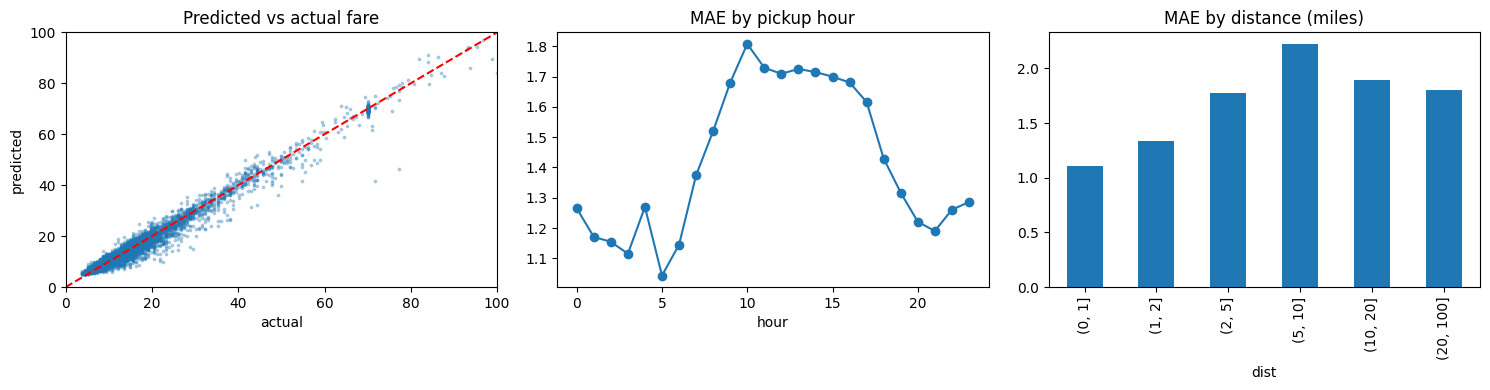

In [7]:
err = pd.DataFrame({'actual': test[TARGET].values, 'pred': pred_nn, 'hour': test['hour'].values, 'dist': test['trip_distance'].values})
err['abs_err'] = (err['actual'] - err['pred']).abs()

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
idx = err.sample(min(5000, len(err)), random_state=1)
ax[0].scatter(idx['actual'], idx['pred'], s=3, alpha=.3); ax[0].plot([0, 100], [0, 100], 'r--'); ax[0].set_xlim(0, 100); ax[0].set_ylim(0, 100)
ax[0].set_title('Predicted vs actual fare'); ax[0].set_xlabel('actual'); ax[0].set_ylabel('predicted')
err.groupby('hour')['abs_err'].mean().plot(ax=ax[1], marker='o'); ax[1].set_title('MAE by pickup hour')
err.groupby(pd.cut(err['dist'], [0, 1, 2, 5, 10, 20, 100]), observed=True)['abs_err'].mean().plot.bar(ax=ax[2]); ax[2].set_title('MAE by distance (miles)')
plt.tight_layout(); plt.savefig(str(RESULTS / 'final_error_analysis.png'), dpi=150); plt.show()

## 4. Inference cost

In [8]:
t0 = time.time(); _ = predict_dollars(model, xte, best_cfg); secs = time.time() - t0
print(f'{len(test):,} predictions in {secs:.2f}s ({len(test)/secs:,.0f} per second); parameters: {model.count_params():,}')

248,510 predictions in 1.43s (173,236 per second); parameters: 53,729


## Notes for the report (critical evaluation)
- Compare the NN with linear regression and random forest; say whether the extra complexity is justified.
- Discuss limitations: sampling, only 3 months, local Spark, no weather/traffic features, fares include rule-based components.
- Discuss scalability: Spark scales horizontally, the Keras model is trained on a sample on one machine; mention distributed training (e.g. Horovod, TF distribution strategies, Spark + Petastorm) as future work.

In [9]:
# Optional: download this stage's results (tables/figures) because the Colab session is temporary
try:
    import shutil
    from google.colab import files
    shutil.make_archive('/content/results_stage6', 'zip', str(BASE / 'results'))
    files.download('/content/results_stage6.zip')
except Exception as e:
    print('download skipped:', e)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>